# Landsat 9 Spectral Signatures by Land Cover Class — Gauteng

This section serves as a continuation from [Mapping with Satellite imagery](). In **Mapping with Satellite imagery**, we learned how to read satellite imagery, visualise it, and calculate band indexesfrom it. We only made mention of spectral resolutions and spectral signatures. In this sectiion, we will be working to visualise spectral signature plots per land cover type using Landsat 9 surface reflectance bands (B1-B7) and land cover classes from the 2022 South African National Land Cover (SANLC).

### Data used

We will access some Landsat data from this USGS EarthExplorer. You can download data from here: https://earthexplorer.usgs.gov
(You are more than welcome to reuse the Landsat data you downloaded in the previous section to work on this.)

The 2022 South African National Land Cover (SANLC) can be downloaded from the Department of Foresty, Fisheries & the Environment's site: https://www.dffe.gov.za/egis

Just as I stated before: Since we will not be using all the `.tif` files downloaded from the Landsat zip file, I would suggest deleting all other files except those labelled with B1 - B7. That way you do not waste storage space.

### Options & libraries

In [1]:
options(
  repr.plot.width  = 12,
  repr.plot.height = 7,
  repr.plot.res    = 200
)

In [3]:
library(tidyverse)
library(terra)
library(sf)
library(scales)

### Load Landsat 9 bands B1–B7

We build the file paths programmatically so adding/removing bands later only requires changing the band numbers vector, nothing else.

Landsat 9 Collection 2 Level-2 band mapping:
- B1 — Coastal aerosol   (0.43–0.45 µm)
- B2 — Blue              (0.45–0.51 µm)
- B3 — Green             (0.53–0.59 µm)
- B4 — Red               (0.64–0.67 µm)
- B5 — Near Infrared     (0.85–0.88 µm)
- B6 — SWIR-1            (1.57–1.65 µm)
- B7 — SWIR-2            (2.11–2.29 µm)

In [6]:
LandsatDir  <- "Data/Gauteng_Landsat"
LandsatBase <- "LC09_L2SP_170078_20260210_20260211_02_T1_SR_B"

BandPaths <- paste0(LandsatDir, "/", LandsatBase, 1:7, ".TIF")

In [7]:
# Verify all files exist before loading
stopifnot("Some band files are missing — check your directory" =
            all(file.exists(BandPaths)))

In [8]:
# Short names for data wrangling
BandNamesShort <- c("B1_Coastal", "B2_Blue",  "B3_Green",
                    "B4_Red",     "B5_NIR",   "B6_SWIR1", "B7_SWIR2")

Wavelengths <- c(0.443, 0.482, 0.561, 0.655, 0.865, 1.609, 2.201)

### Apply Landsat Collection 2 scale factor

Usually Level-2 Surface Reflectance products store values as scaled integers. The official USGS scale factor is 0.0000275 with an offset of -0.2. After applying this, values should fall between 0 and 1 (occasionally slightly above 1 for bright surfaces — this is normal).

Values $<=$ 0 after scaling are either fill/cloud pixels and we have to mask them out.

In [9]:
LandsatStack <- rast(BandPaths) * 0.0000275 - 0.2

In [10]:
# Mask out invalid pixels (fill value in raw data is 0; after scaling → -0.2)
LandsatStack[LandsatStack < 0] <- NA

In [11]:
names(LandsatStack) <- BandNamesShort

In [12]:
print(LandsatStack)

class       : SpatRaster 
size        : 7821, 7751, 7  (nrow, ncol, nlyr)
resolution  : 30, 30  (x, y)
extent      : 533085, 765615, -2993415, -2758785  (xmin, xmax, ymin, ymax)
coord. ref. : WGS 84 / UTM zone 35N (EPSG:32635) 
source      : spat_19436e642090_6467_CjcR62DykkoqBId.tif 
names       :   B1_Coastal,      B2_Blue,     B3_Green,       B4_Red,       B5_NIR,     B6_SWIR1, ... 
min values  : 7.498264e-06, 7.498264e-06, 7.498264e-06, 7.498264e-06, 7.498264e-06, 7.498264e-06, ... 
max values  : 1.374622e+00, 1.377482e+00, 1.470405e+00, 1.446782e+00, 1.444500e+00, 1.511050e+00, ... 


### Load the 2022 SA National Land Cover
The SANLC is distributed in South African Albers Equal Area projection.

We need to:

1. Load it
2. Crop it to the Landsat extent (much faster than reprojecting the whole SA)
3. Reproject/resample to exactly match Landsat's CRS, extent, and resolution

In [13]:
LandCoverPath <- "Data/SA_NLC_2022_ALBERS/SA_NLC_2022_ALBERS.tif"

stopifnot("Land cover file not found — check your directory" =
            file.exists(LandCoverPath))

In [14]:
LandCover_Raw <- rast(LandCoverPath)

In [15]:
print(LandCover_Raw)

class       : SpatRaster 
size        : 72429, 86309, 1  (nrow, ncol, nlyr)
resolution  : 20, 20  (x, y)
extent      : -894267, 831913, -3796067, -2347487  (xmin, xmax, ymin, ymax)
coord. ref. : +proj=aea +lat_0=0 +lon_0=25 +lat_1=-24 +lat_2=-33 +x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs 
source      : SA_NLC_2022_ALBERS.tif 
color table : 1 
categories  : Class_Name, SALCC_1, SALCC_2, Opacity, Count 
name        :                          Class_Name 
min value   :                                     
max value   : fallow land & old fields (wetlands) 


Now we have to project the Landsat extent into Albers so we can crop the land cover first. 

In [16]:
LandsatExtent_Albers <- project(
  ext(LandsatStack),
  from = crs(LandsatStack),
  to   = crs(LandCover_Raw)
)

Now we reproject the land cover to match Landsat exactly.

`method = "near"` is critical for categorical data — nearest neighbour preserves class integer codes; bilinear interpolation would corrupt them.

In [17]:
LandCover_Matched <- LandCover_Raw %>%
  crop(LandsatExtent_Albers) %>%
  project(LandsatStack, method = "near")

Warning message in x@pntr$warp(y@pntr, "", method, mask[1], align_only[1], FALSE, :
“GDAL Error 6: spat_19431e8d5d04_6467_gpOs7emPHgpsidG.tif, band 1: SetColorTable() only supported for Byte or UInt16 bands in TIFF format.”


In [18]:
print(LandCover_Matched)

class       : SpatRaster 
size        : 7821, 7751, 1  (nrow, ncol, nlyr)
resolution  : 30, 30  (x, y)
extent      : 533085, 765615, -2993415, -2758785  (xmin, xmax, ymin, ymax)
coord. ref. : WGS 84 / UTM zone 35N (EPSG:32635) 
source      : spat_19431e8d5d04_6467_gpOs7emPHgpsidG.tif 
color table : 1 
categories  : Class_Name, SALCC_1, SALCC_2, Opacity, Count 
name        :                          Class_Name 
min value   :      contiguous (indigenous) forest 
max value   : fallow land & old fields (wetlands) 


### Read the land cover class legend

The SANLC stores class labels in the raster's built-in category table, not in the DBF (which only holds pixel values and opacity). We will use `cats()` to extract this table; the first column is always the integer code.

In [19]:
RawCats <- cats(LandCover_Matched)[[1]]

In [20]:
print(names(RawCats))

[1] "Value"      "Class_Name" "SALCC_1"    "SALCC_2"    "Opacity"   
[6] "Count"     


Now we will have to find the column that holds the meaningful class name. We pick the first character column that is not just a number or hex colour.

In [22]:
CharCols <- names(RawCats)[sapply(RawCats, is.character)]

cat("Character columns available:", paste(CharCols, collapse = ", "), "\n")

Character columns available: Class_Name, SALCC_1, SALCC_2 


In [23]:
# Use Class_Name if present, otherwise fall back to the first character column
NameCol <- if ("Class_Name" %in% CharCols) "Class_Name" else CharCols[1]

In [24]:
ClassLegend <- RawCats %>%
  as_tibble() %>%
  rename_with(tolower) %>%
  mutate(class_code = as.integer(.[[1]])) %>%
  rename(class_name = tolower(NameCol)) %>%
  select(class_code, class_name) %>%
  mutate(class_name = as.character(class_name)) %>%
  distinct(class_code, .keep_all = TRUE) %>%
  filter(!is.na(class_code))

In [25]:
print(ClassLegend, n = 20)

# A tibble: 256 × 2
   class_code class_name                                            
        <int> <chr>                                                 
 1          0 ""                                                    
 2          1 "contiguous (indigenous) forest"                      
 3          2 "contiguous low forest & thicket"                     
 4          3 "dense forest & woodland"                             
 5          4 "open woodland"                                       
 6          5 "contiguous & dense plantation forest"                
 7          6 "open & sparse plantation forest"                     
 8          7 "temporary unplanted (clear-felled) plantation forest"
 9          8 "low shrubland (other)"                               
10          9 "low shrubland (fynbos)"                              
11         10 "low shrubland (succulent karoo)"                     
12         11 "low shrubland (nama karoo)"                          
13         12 

### Discover classes present in the Gauteng extent

We take a large random sample from the matched land cover raster to find which class codes actually exist in this area — avoids wasting time looping over national classes that don't appear in Gauteng at all. 

In [26]:
ClassCodes <- spatSample(
  LandCover_Matched,
  size   = 100000,
  method = "random",
  na.rm  = TRUE,
  as.df  = TRUE
) %>%
  pull(1) %>%
  as.integer() %>%
  unique() %>%
  sort() %>%
  na.omit()

In [27]:
cat("\n── Classes present in Gauteng extent:", length(ClassCodes), "──────\n")
print(ClassCodes)


── Classes present in Gauteng extent: 58 ──────
 [1]  2  3  4  5  6  7  8  9 13 14 15 19 20 21 22 23 24 26 27 28 31 32 33 39 40
[26] 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65
[51] 66 67 68 69 70 72 73 74


### Sample Landsat reflectance per class

For each class we mask the land cover to that class only, draw 200 random points within it, then extract the Landsat band values at those locations.

Processing one class at a time keeps peak memory low and avoids R crashing. This is part of the reason we did not use the `spatSample` approach. `trycatch` handles classes with too few pixels gracefully

In [28]:
SampledList <- lapply(ClassCodes, function(code) {

  ClassMask <- ifel(LandCover_Matched == code, 1, NA)

  pts <- tryCatch(
    spatSample(ClassMask, size = 200, method = "random",
               na.rm = TRUE, as.points = TRUE),
    error = function(e) NULL
  )

  if (is.null(pts) || nrow(pts) == 0) return(NULL)

  vals <- extract(LandsatStack, pts, ID = FALSE)
  vals$class_code <- as.integer(code)
  vals
})

Warning message:
“[spatSample] fewer cells returned than requested”


Warning message:
“[spatSample] fewer cells returned than requested”


Warning message:
“[spatSample] fewer cells returned than requested”


Warning message:
“[spatSample] fewer cells returned than requested”


Warning message:
“[spatSample] fewer cells returned than requested”


...

Warning message:
“[spatSample] fewer cells returned than requested”


Warning message:
“[spatSample] fewer cells returned than requested”


Warning message:
“[spatSample] fewer cells returned than requested”
Warning message:
“[extract] nothing to extract”


Warning message:
“[spatSample] fewer cells returned than requested”


Warning message:
“[spatSample] fewer cells returned than requested”


In [29]:
# Combine all classes into one data frame
SampledPixels <- bind_rows(SampledList)

cat("   Total pixels sampled:", nrow(SampledPixels), "\n")
cat("   Classes represented: ", n_distinct(SampledPixels$class_code), "\n")

   Total pixels sampled: 892 
   Classes represented:  30 


### Tidy the sampled data

Pivot from wide (one column per band) to long (one row per band per pixel) so that `{ggplot2}` can map band onto the x-axis directly.

In [30]:
BandWavelength <- tibble(
  band_name  = BandNamesShort,
  wavelength = Wavelengths
)

In [31]:
SampledLong <- SampledPixels %>%
  as_tibble() %>%
  mutate(class_code = as.integer(class_code)) %>%
  pivot_longer(
    cols      = all_of(BandNamesShort),
    names_to  = "band_name",
    values_to = "reflectance"
  ) %>%
  left_join(BandWavelength, by = "band_name") %>%
  left_join(ClassLegend,   by = "class_code") %>%
  mutate(
    class_name  = as.character(class_name),
    class_label = if_else(!is.na(class_name) & class_name != "",
                          class_name,
                          as.character(class_code))
  ) %>%
  filter(!is.na(reflectance), !is.na(class_code))

print(head(SampledLong, 5))

# A tibble: 5 × 6
  class_code band_name  reflectance wavelength class_name            class_label
       <int> <chr>            <dbl>      <dbl> <chr>                 <chr>      
1          3 B1_Coastal      0.0172      0.443 dense forest & woodl… dense fore…
2          3 B2_Blue         0.0213      0.482 dense forest & woodl… dense fore…
3          3 B3_Green        0.0424      0.561 dense forest & woodl… dense fore…
4          3 B4_Red          0.0412      0.655 dense forest & woodl… dense fore…
5          3 B5_NIR          0.295       0.865 dense forest & woodl… dense fore…


### Compute mean signature per class

In [32]:
SpectralSignatures <- SampledLong %>%
  group_by(class_label, band_name, wavelength) %>%
  summarise(
    mean_ref = mean(reflectance, na.rm = TRUE),
    sd_ref   = sd(reflectance,   na.rm = TRUE),
    n        = n(),
    .groups  = "drop"
  )

print(SpectralSignatures, n = 10)

# A tibble: 210 × 6
   class_label                        band_name wavelength mean_ref sd_ref     n
   <chr>                              <chr>          <dbl>    <dbl>  <dbl> <int>
 1 artificial dams (including canals) B1_Coast…      0.443   0.0277 0.0246     8
 2 artificial dams (including canals) B2_Blue        0.482   0.0392 0.0297     8
 3 artificial dams (including canals) B3_Green       0.561   0.0757 0.0398     8
 4 artificial dams (including canals) B4_Red         0.655   0.0696 0.0534     8
 5 artificial dams (including canals) B5_NIR         0.865   0.0639 0.0873     8
 6 artificial dams (including canals) B6_SWIR1       1.61    0.0510 0.111      8
 7 artificial dams (including canals) B7_SWIR2       2.20    0.0423 0.0971     8
 8 commercial                         B1_Coast…      0.443   0.0495 0.0306     2
 9 commercial                         B2_Blue        0.482   0.0643 0.0208     3
10 commercial                         B3_Green       0.561   0.128  0.0247     3
# ℹ 200 

### Choose which classes to plot

I chose to plot only 5 classes because having anything more than that would most likely create an unreadable mess. To make things better and easier for us, we will make it so that we keep the top N classes by pixel count and lump the rest as "Other". 

Adjust `TopN` to show more or fewer classes.

In [38]:
TopN <- 5

TopClasses <- SampledLong %>%
  count(class_label, sort = TRUE) %>%
  slice_head(n = TopN) %>%
  pull(class_label)

SignaturesPlot <- SpectralSignatures %>%
  filter(class_label %in% TopClasses)

### Spectral signature plot

A classic spectral signature plot looks something like this:

- x-axis  = wavelength (µm) — represents the electromagnetic spectrum
- y-axis  = mean surface reflectance (0–1)
- colour  = land cover class
- ribbon  = ± 1 SD around the mean (shows within-class variability)

In [39]:
NClasses <- n_distinct(SignaturesPlot$class_label)

In [40]:
# Use a colour palette that distinguishes many categories clearly on dark bg
ClassColours <- colorRampPalette(c(
  "#f48fb1", "#80cbc4", "#fff176", "#ef9a9a", "#ce93d8",
  "#80deea", "#a5d6a7", "#ffcc80", "#90caf9", "#bcaaa4",
  "#ffe082", "#b39ddb"
))(NClasses)

Plot spectral signature profiles.

In [41]:
SpectralSigPlot <- SignaturesPlot %>%
  ggplot(aes(x = wavelength, y = mean_ref,
             colour = class_label, fill = class_label)) +

  # ± 1 SD ribbon
  geom_ribbon(
    aes(ymin = pmax(mean_ref - sd_ref, 0),
        ymax = mean_ref + sd_ref),
    alpha  = 0.10,
    colour = NA
  ) +

  # Mean signature line
  geom_line(linewidth = 0.9) +

  # Band centre points
  geom_point(size = 2.8, shape = 21, fill = "white", stroke = 1) +

  # Dotted vertical lines at band centres
  geom_vline(xintercept = Wavelengths,
             colour = "white", linewidth = 0.2,
             linetype = "dotted", alpha = 0.25) +

  # Band labels at top
  annotate("text",
           x = Wavelengths, y = Inf,
           label  = paste0("B", 1:7),
           vjust  = -0.5, size = 2.8,
           colour = "grey55") +

  scale_colour_manual(values = ClassColours, name = "Land Cover Class") +
  scale_fill_manual(values   = ClassColours, name = "Land Cover Class") +

  scale_x_continuous(
    name   = "Wavelength (µm)",
    breaks = Wavelengths,
    labels = round(Wavelengths, 3)
  ) +
  scale_y_continuous(
    name   = "Surface Reflectance",
    labels = label_number(accuracy = 0.01),
    expand = expansion(mult = c(0.02, 0.1))
  ) +

  labs(
    title    = "Spectral Signatures by Land Cover Class — Gauteng",
    subtitle = paste0(
      "Landsat 9 Collection 2 · 2022 SA National Land Cover · ",
      "Top ", TopN, " classes · Ribbon = ±1 SD"
    ),
    caption = "Scene: LC09_L2SP_170078 · Acquired: 2026-02-10 · USGS Collection 2 Level-2 SR"
  ) +

  theme_minimal(base_family = "sans") +
  theme(
    plot.background   = element_rect(fill = "#070b1a", colour = NA),
    panel.background  = element_rect(fill = "#070b1a", colour = NA),
    panel.grid.major  = element_line(colour = "#ffffff10", linewidth = 0.3),
    panel.grid.minor  = element_blank(),
    panel.border      = element_rect(colour = "#ffffff18", fill = NA,
                                     linewidth = 0.5),
    plot.title        = element_text(colour = "#eceff1", face = "bold",
                                     size = 14, margin = margin(b = 4)),
    plot.subtitle     = element_text(colour = "#78909c", size = 9,
                                     margin = margin(b = 10)),
    plot.caption      = element_text(colour = "#546e7a", size = 7.5),
    axis.text         = element_text(colour = "#90a4ae", size = 8),
    axis.text.x       = element_text(angle = 30, hjust = 1),
    axis.title        = element_text(colour = "#b0bec5", size = 10),
    legend.background = element_rect(fill = "#0a0f1e", colour = "#ffffff12"),
    legend.text       = element_text(colour = "#b0bec5", size = 8),
    legend.title      = element_text(colour = "#eceff1", size = 9,
                                     face = "bold"),
    legend.key        = element_rect(fill = NA),
    plot.margin       = margin(14, 16, 12, 14)
  )

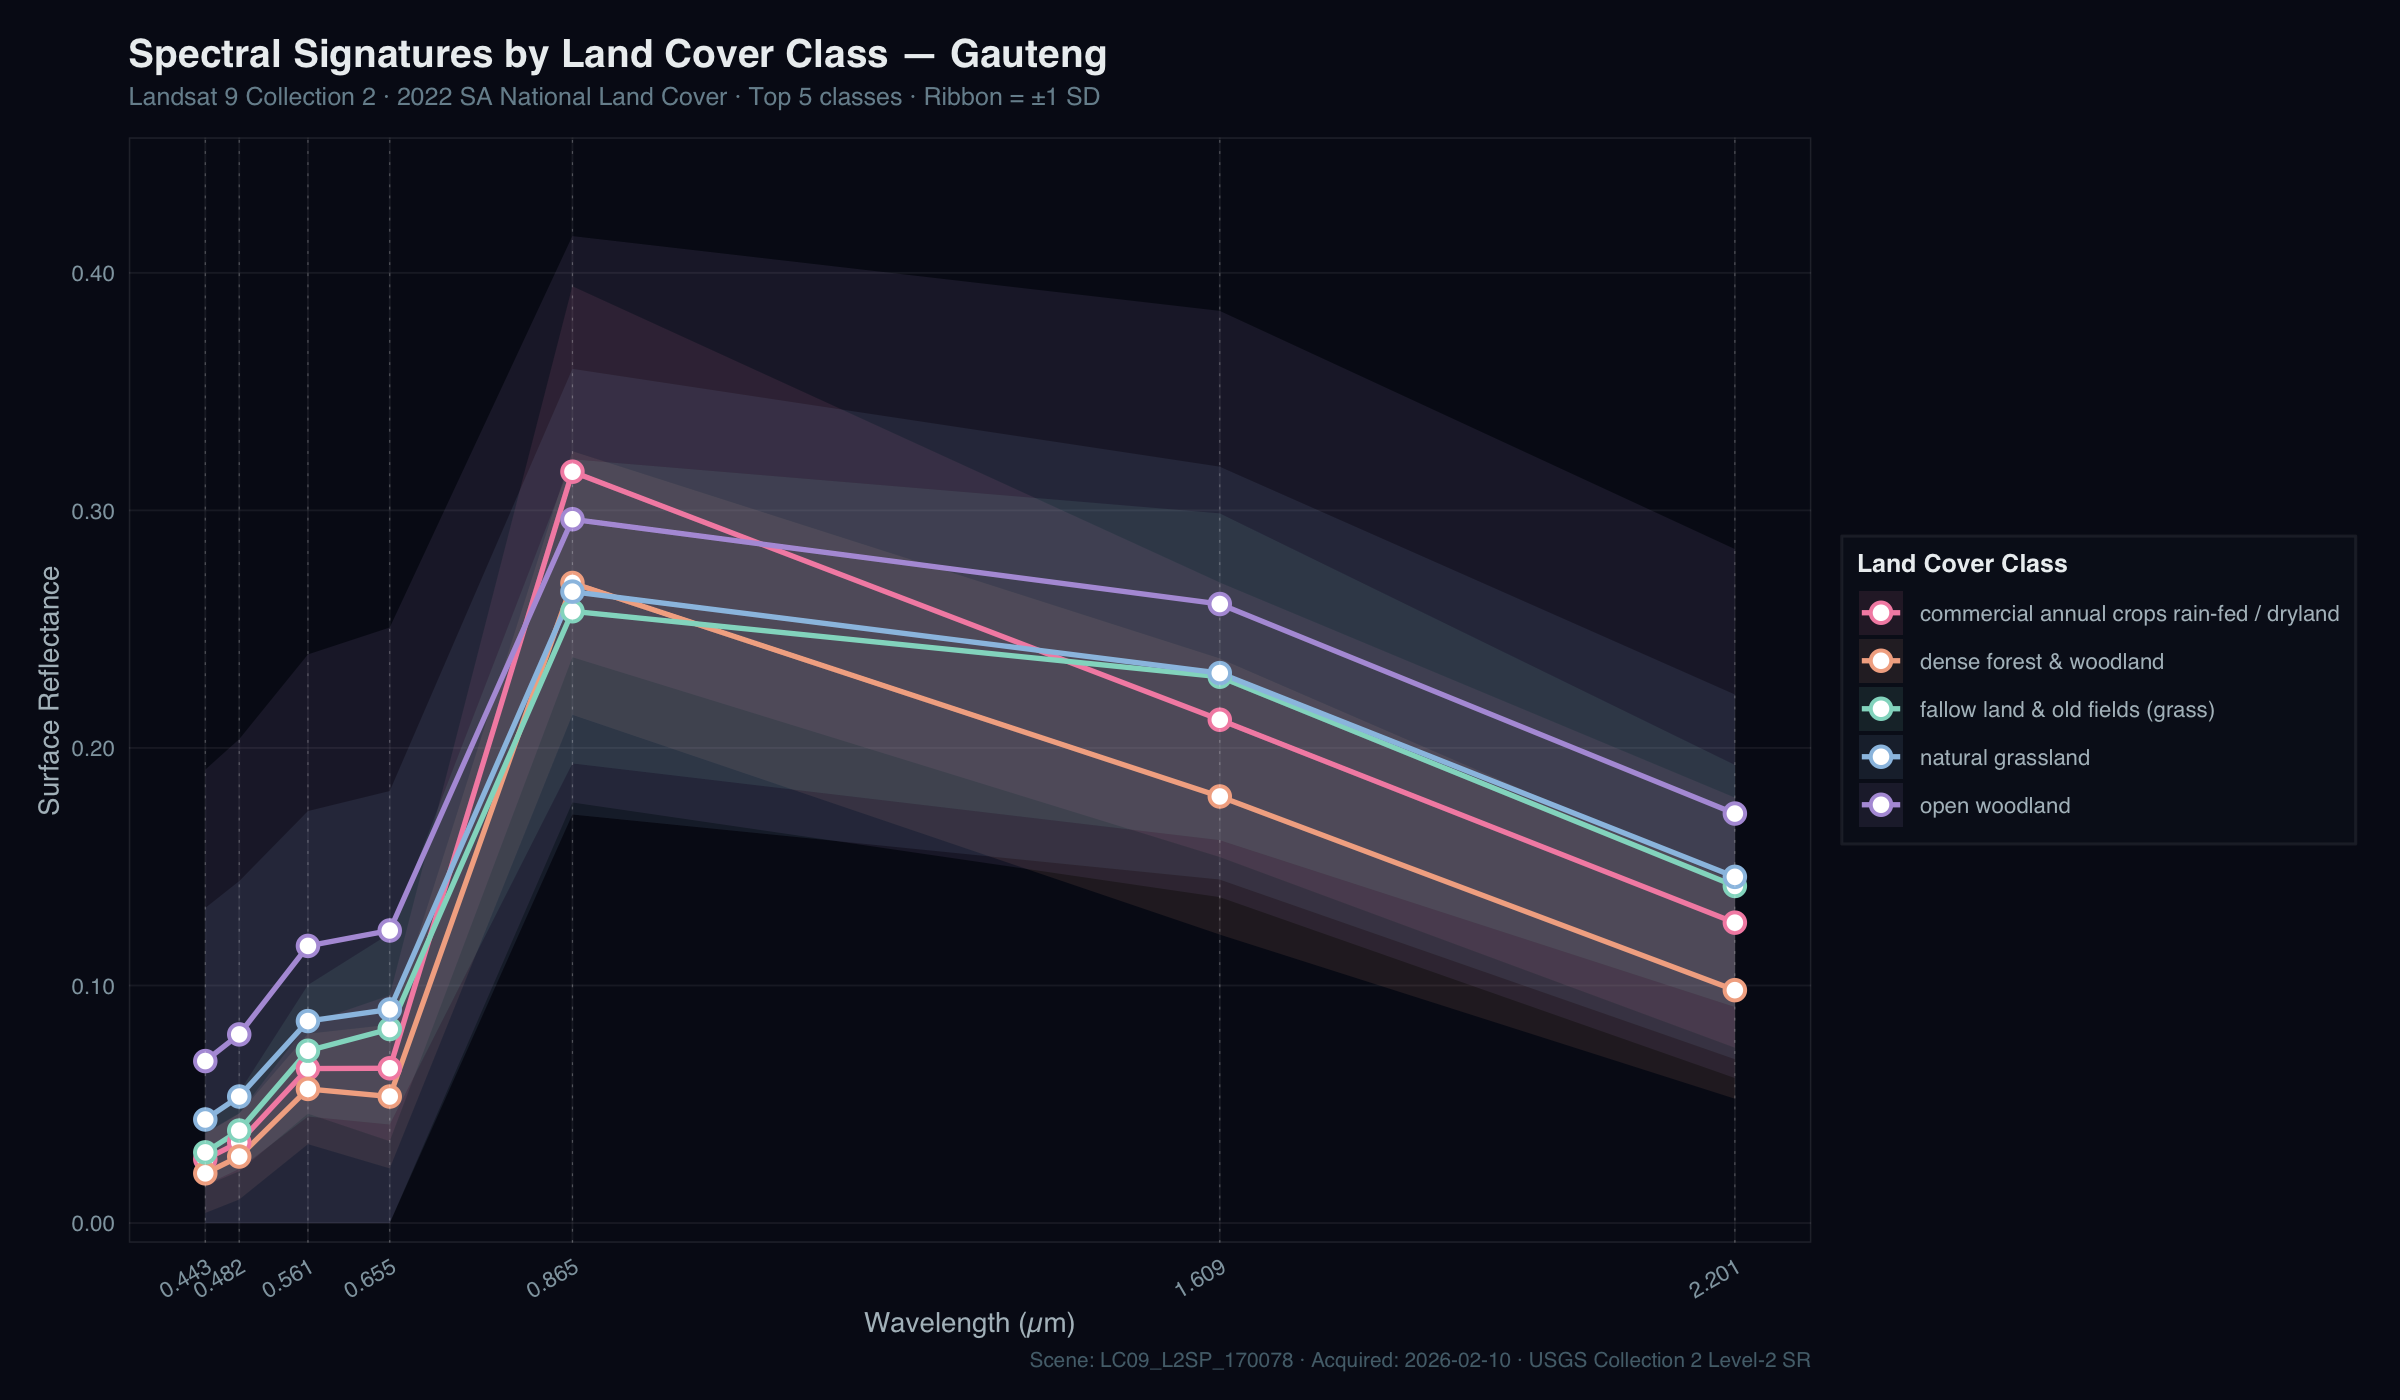

In [42]:
print(SpectralSigPlot)